In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.helper_functions import fit_gaussian

In [129]:
df = pd.read_csv('csvs/final_fit_Run3.csv')

In [130]:
import ast

# read ntuples as ntuples
corrections_df = pd.read_csv("data_fit_summary_Run3_with_plot_coeff.csv")
corrections_df['coeff_data'] = corrections_df['coeff_data'].apply(ast.literal_eval)
# corrections_df['coeff_chr_BPIX'] = corrections_df['coeff_chr_BPIX'].apply(ast.literal_eval)
# corrections_df['coeff_chr_FPIX'] = corrections_df['coeff_chr_FPIX'].apply(ast.literal_eval)
# corrections_df['coeff_eff'] = corrections_df['coeff_eff'].apply(ast.literal_eval)
corrections_df['coeff_combined'] = corrections_df['coeff_combined'].apply(ast.literal_eval)
# corrections_df['plot_coeff'] = corrections_df['plot_coeff'].apply(ast.literal_eval)
corrections_df['run_range'] = corrections_df['run_range'].apply(ast.literal_eval)
corrections_df['int_lumi_range'] = corrections_df['int_lumi_range'].apply(ast.literal_eval)

corrections_df

,region,coeff_data,sigma,n_points,run_range,int_lumi_range,coeff_combined
0,2024a,"(-0.002331735205800725, 1.0)","[0.00014411187697925778, 0.0024726039809270855]",1502,"(379416, 381544)","(74.98679337792825, 105.04793697590138)","(-0.0027756520999642604, 1.0)"
1,2024b,"(-0.002781643267830591, 1.0)","[7.203276024525343e-05, 0.0013364894308142185]",1417,"(382251, 383855)","(105.39032592192488, 137.8786325105323)","(-0.0024152248459754348, 1.0)"
2,2024c,"(-0.0015407308406327602, 1.0)","[5.941670883828747e-05, 0.0012289916363455897]",1444,"(383907, 385515)","(137.91739082554855, 173.07735836901222)","(-0.0023550962110604205, 1.0)"


In [131]:
def apply_corrections(df, corrections_df):
    df = df.copy()
    # df["final_ratio_corr"] = df["final_ratio"]  # start with original
    df["final_ratio_corr"] = 0.75
    
    for _, row in corrections_df.iterrows():
        # ### apply required correction and mean normalization ###
        # run_min, run_max = row["run_range"]
        # lumi_min, lumi_max = row["int_lumi_range"]
        # a, b = row["coeff_data"]
        # print(a, b)

        # # mask rows within this run range
        # mask = (df["run"] >= run_min) & (df["run"] <= run_max)

        # # shift int_lumi relative to lumi_min
        # shifted_lumi = df.loc[mask, "int_lumi"] - lumi_min
        # # compute correction factor
        # corr_factor = a + b * shifted_lumi
        # # apply correction
        # df.loc[mask, "final_ratio_corr"] = df.loc[mask, "final_ratio"] / corr_factor

        # then divide by the mean of the corrected ratio
        # mean_corr = df.loc[mask, "final_ratio_corr"].mean()
        # df.loc[mask, "final_ratio_corr"] /= mean_corr
        
        ### apply correction based on efficiency segments
        # run_min, run_max = row["run_range"]
        # lumi_min, lumi_max = row["int_lumi_range"]
        # a, b = row["coeff_eff"]

        # # mask rows within this run range
        # mask = (df["run"] >= run_min) & (df["run"] <= run_max)

        # # shift int_lumi relative to lumi_min
        # shifted_lumi = df.loc[mask, "int_lumi"] - lumi_min

        # # apply correction (divide by intercept only)
        # # df.loc[mask, "final_ratio_corr"] = df.loc[mask, "final_ratio"] / a

        # # print(f"Applying efficiency correction for runs {run_min}-{run_max} with coeffs: a={a}, b={b}")

        ## apply linear chr correction
        run_min, run_max = row["run_range"]
        lumi_min, lumi_max = row["int_lumi_range"]
        b, a = row["coeff_combined"]
        # print(f"Applying combined correction for runs {run_min}-{run_max} with coeffs: a={a}, b={b}")

        # b = 1 - (1 - b)**2 # squared correction

        # mask rows within this run range
        mask = (df["run"] >= run_min) & (df["run"] <= run_max)

        # shift int_lumi relative to lumi_min
        shifted_lumi = df.loc[mask, "integrated_lumi"] - lumi_min
        # print(shifted_lumi)
        # compute correction factor
        corr_factor = a + b * shifted_lumi
        # corr_factor = 1 + b * shifted_lumi

        jump = 1
        region = row["region"]
        if region == "2024a":
            # jump = 1.019
            # jump = 1.051
            jump = 1.043
        elif region == "2024b":
            # jump = 0.969
            # jump = 1.002
            jump = 0.982
        elif region == "2024c":
            # jump = 0.909
            # jump = 0.953
            jump = 0.947
        else:
            print("Unknown region:", region)
            jump = 1.0

        # apply correction
        # df.loc[mask, "final_ratio_corr"] = df.loc[mask, "final_ratio"] / 0.8*a #(2*a)
        df.loc[mask, "final_ratio_corr"] = df.loc[mask, "final_ratio"] / corr_factor / jump

    return df

df_corrected = apply_corrections(df, corrections_df)

In [132]:
df_corrected

,bin_key,run,lumiblock,events,events_error,lumi,pileup,nPV,nPV_err,year,era,integrated_lumi,events_scaled,final_ratio,final_ratio_corr
0,355872_0,355872,0,15.073523,0.148780,2.280727,32.067347,21.826864,4.995784,2022,C1,0.153622,2.093545,0.917929,0.75
1,355872_50,355872,50,14.378232,0.165042,2.124518,32.934000,22.387277,5.108585,2022,C1,0.156806,1.996977,0.939967,0.75
2,355872_100,355872,100,16.709624,0.654853,2.410001,34.028000,23.039276,5.008328,2022,C1,0.160095,2.320781,0.962979,0.75
3,355872_150,355872,150,16.370865,0.354035,2.433746,34.422000,23.252091,5.053527,2022,C1,0.163423,2.273731,0.934252,0.75
4,355872_200,355872,200,16.292962,0.207220,2.465541,34.268000,23.161099,5.020140,2022,C1,0.166735,2.262911,0.917815,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10816,395172_400,395172,400,131.551830,0.629896,18.985194,60.614000,38.822437,6.880814,2025,D1,234.079938,18.271087,0.962386,0.75
10817,395172_450,395172,450,137.672900,0.509971,19.956325,60.548000,38.778897,6.844373,2025,D1,234.104220,19.121236,0.958154,0.75
10818,395172_500,395172,500,135.913899,0.540254,19.629565,60.468000,38.671418,6.813787,2025,D1,234.128472,18.876930,0.961658,0.75
10819,395172_550,395172,550,135.564916,0.575429,19.635660,60.550000,38.749074,6.817242,2025,D1,234.152762,18.828460,0.958891,0.75


In [133]:
# remove outliers
# df_corrected = df_corrected[(df_corrected['final_ratio_corr'] > 0.6) & (df_corrected['final_ratio_corr'] < 1.8)]

# keep only the run ranges in the corrections_df
print("Number of LS before applying run ranges:", len(df_corrected))
run_ranges = corrections_df['run_range'].tolist()
mask = np.zeros(len(df_corrected), dtype=bool)
for run_min, run_max in run_ranges:
    mask |= (df_corrected['run'] >= run_min) & (df_corrected['run'] <= run_max)
df_corrected = df_corrected[mask]
print(f"Number of LS after applying run ranges: {len(df_corrected)}")

Number of LS before applying run ranges: 10821
Number of LS after applying run ranges: 4363


Region 2024a: mean: 1.000
Region 2024b: mean: 0.938
Region 2024c: mean: 0.903


(0.7, 1.2)

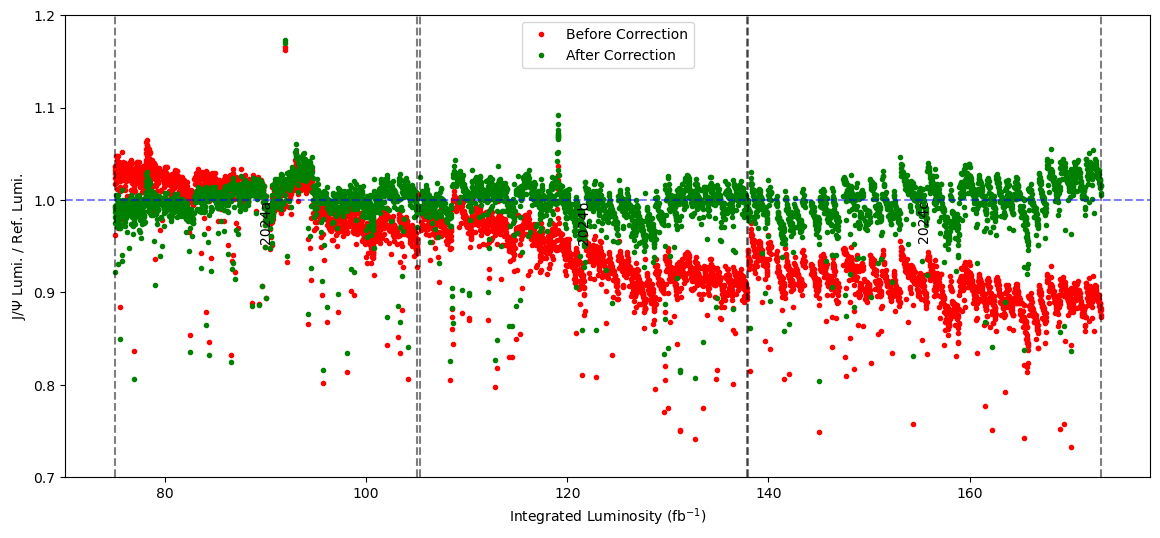

In [134]:
plt.figure(figsize=(14, 6))
for _, row in corrections_df.iterrows():
    run_min, run_max = row["run_range"]
    region_mask = (df_corrected['run'] >= run_min) & (df_corrected['run'] <= run_max)
    region_df = df_corrected[region_mask]
    lumi_min, lumi_max = row["int_lumi_range"]

    plt.plot(region_df["integrated_lumi"], region_df["final_ratio"], '.r')
    plt.plot(region_df["integrated_lumi"], region_df["final_ratio_corr"], '.g')

    print(f"Region {row['region']}: mean: {region_df['final_ratio'].mean():.3f}")

    # # Mark era boundaries
    plt.axvline(lumi_min, color='k', linestyle='--', alpha=0.5)
    plt.axvline(lumi_max, color='k', linestyle='--', alpha=0.5)
    plt.text((lumi_min + lumi_max) / 2,
             1.0,   # near top
             row['region'],
             ha='center', va='top', rotation=90)
    # break
# draw horizontal line at y=1
plt.axhline(1, color='b', linestyle='--', alpha=0.5)
plt.xlabel('Integrated Luminosity (fb$^{-1}$)')
plt.ylabel('J/$\Psi$ Lumi. / Ref. Lumi.')
plt.legend(['Before Correction', 'After Correction'])
plt.ylim([0.7, 1.2])

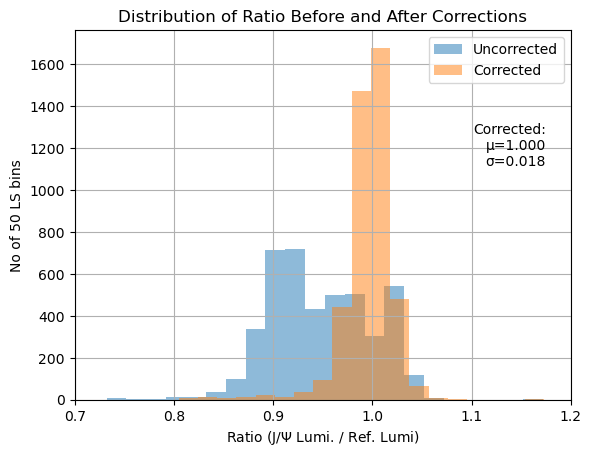

In [135]:
# there are some negative values in the ratio, it is not possible. Need to investigate
plt.hist(df_corrected['final_ratio'], bins=100, alpha=0.5, label='Uncorrected')
# _, me, si = fit_gaussian(df_corrected['final_ratio'], bins=100, plot=False)
# plt.text(0.95, 0.9, f'Uncorrected:\nμ={me:.3f}\nσ={si:.3f}', 
#          horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes)

plt.hist(df_corrected['final_ratio_corr'], bins=100, alpha=0.5, label='Corrected')
_, me, si = fit_gaussian(df_corrected['final_ratio_corr'], bins=100, plot=False)
plt.text(0.95, 0.75, f'Corrected:\nμ={me:.3f}\nσ={si:.3f}', 
         horizontalalignment='right', verticalalignment='top', transform=plt.gca().transAxes)

plt.xlabel('Ratio (J/$\Psi$ Lumi. / Ref. Lumi)')
plt.ylabel('No of 50 LS bins')
plt.title('Distribution of Ratio Before and After Corrections')
plt.legend()
plt.xlim([0.7, 1.2])
plt.grid()

Region 2024a Corrected: mean: 1.000 ± 0.015
Region 2024b Corrected: mean: 1.000 ± 0.016
Region 2024c Corrected: mean: 1.000 ± 0.022


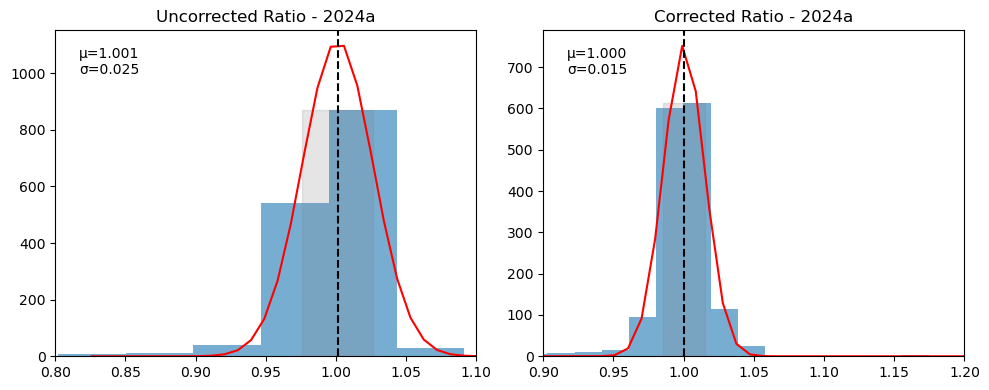

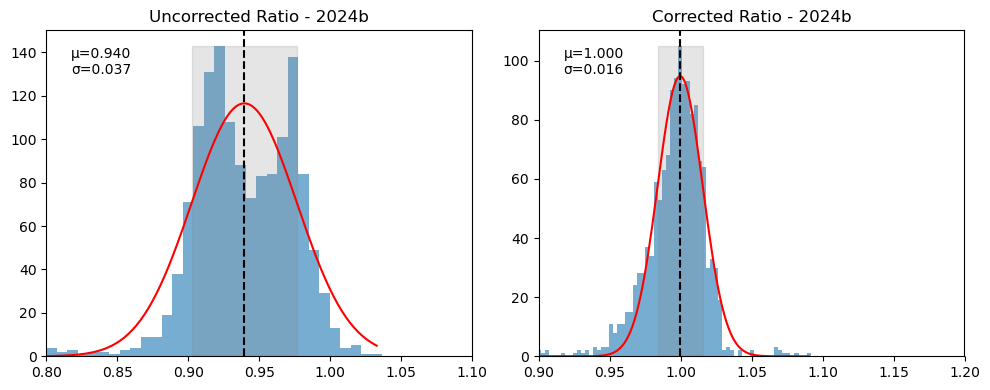

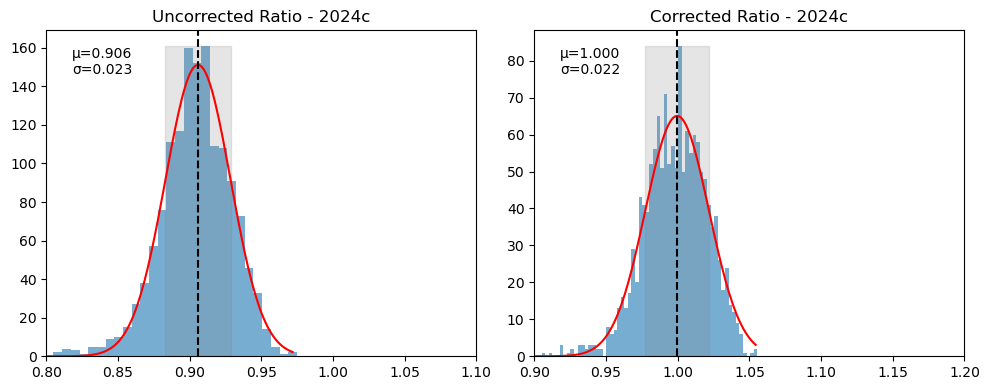

In [136]:
for _, row in corrections_df.iterrows():
    run_min, run_max = row["run_range"]
    region_mask = (df_corrected['run'] >= run_min) & (df_corrected['run'] <= run_max)
    region_df = df_corrected[region_mask]
    lumi_min, lumi_max = row["int_lumi_range"]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    fit_gaussian(region_df["final_ratio"], bins=40, ax=ax[0], plot=True)
    ax[0].set_xlim([0.8, 1.1])
    ax[0].set_title(f"Uncorrected Ratio - {row['region']}")

    _, me, si = fit_gaussian(region_df["final_ratio_corr"], bins=100, ax=ax[1], plot=True)
    ax[1].set_xlim([0.9, 1.2])
    ax[1].set_title(f"Corrected Ratio - {row['region']}")
    # plt.suptitle(f"Gaussian Fit of Final Ratio - {row['region']}")
    plt.tight_layout()
    # save figure
    plt.savefig(f'plots/corrected_regions/gaus_{row["region"]}.png')
    # print era mean and sigma
    print(f"Region {row['region']} Corrected: mean: {me:.3f} ± {si:.3f}")
    
    # clear figure
    # plt.clf()
    # plt.cla()
    # break